# Bước 1: Chuẩn bị & Hiểu bối cảnh (Context Understanding)

*   Xác định mục tiêu kinh doanh/dự án. (sinh viên với dữ liệu thực tế này, tự đặt yêu cầu phân tích)
*   Nắm rõ ý nghĩa thực tế của từng biến.

- Phân tích mức lương theo trình độ kinh nghiệm: Tính toán mức lương trung bình (salary_in_usd) cho mỗi cấp độ kinh nghiệm (experience_level) và trực quan hóa kết quả bằng biểu đồ.
- Phân tích mức lương theo quy mô công ty: Tính toán mức lương trung bình (salary_in_usd) cho mỗi quy mô công ty (company_size) và trực quan hóa kết quả bằng biểu đồ.
- Phân tích tác động kết hợp của trình độ kinh nghiệm và quy mô công ty đến mức lương: Nhóm dữ liệu theo cả 'experience_level' và 'company_size', tính mức lương trung bình (salary_in_usd) cho từng nhóm, sau đó trực quan hóa kết quả bằng biểu đồ cột nhóm.
- Đưa ra khuyến nghị nghề nghiệp: Tổng hợp các phát hiện từ phân tích và đưa ra các khuyến nghị nghề nghiệp cụ thể trong lĩnh vực khoa học dữ liệu, tập trung vào cách trình độ kinh nghiệm và quy mô công ty ảnh hưởng đến mức lương.
- Trình bày các phát hiện chính và các khuyến nghị nghề nghiệp dựa trên phân tích.

In [1]:
from google.colab import drive

# Bước 2: Kiểm tra cấu trúc dữ liệu

In [2]:
import pandas as pd

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/data/DataScience_salaries_2024.csv')
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
3,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
4,2022,SE,FT,Lead Machine Learning Engineer,7500000,INR,95386,IN,50,IN,L


In [5]:
print(df.shape)
print(df.info())
print(df.describe())

(14838, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14838 entries, 0 to 14837
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           14838 non-null  int64 
 1   experience_level    14838 non-null  object
 2   employment_type     14838 non-null  object
 3   job_title           14838 non-null  object
 4   salary              14838 non-null  int64 
 5   salary_currency     14838 non-null  object
 6   salary_in_usd       14838 non-null  int64 
 7   employee_residence  14838 non-null  object
 8   remote_ratio        14838 non-null  int64 
 9   company_location    14838 non-null  object
 10  company_size        14838 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.2+ MB
None
          work_year        salary  salary_in_usd  remote_ratio
count  14838.000000  1.483800e+04   14838.000000  14838.000000
mean    2023.138900  1.650227e+05  149874.718763     32.760480
std        

In [6]:
df.sample(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
7775,2023,SE,FT,Data Science Engineer,140000,USD,140000,US,0,US,M
11194,2024,EN,FT,Data Analyst,100000,USD,100000,US,0,US,M
8162,2023,SE,FT,Applied Scientist,136000,USD,136000,US,0,US,L
14261,2023,MI,FT,Data Scientist,50000,EUR,53984,RO,50,RO,L
6734,2023,MI,FT,Data Scientist,150000,USD,150000,US,100,US,M


- work_year: năm dữ liệu được ghi nhận
- experience_level:
  + EN: Entry-level (mới vào ngành)
  + MI: Mid-level (Kinh nghiệm trung bình)
  + SE: Senior-level (Chuyên gia)
  + EX: Executive-level (Head, Director, VP of Data)
- employee_residence: nơi nhân viên sinh sống
- employment_type: loại hợp đồng lao động
  + FT: full-time
  + PT: part-time
  + CT: contract
  + FL: Freelance
- job_title: tên chức danh công việc
  + DS
  + MLE
  + NLP E
  + DS M
  + Lead/Principal roles
- salary_currency
  đơn vị tiền tệ gốc: INR, JPY, HUF, CLP, USD,...
- salary_in_usd: lương quy đổi về usd
- company_location: quốc gia nơi công ty đặt trụ sớ
- company_size: quy mô công ty theo lượng nhân viên
- remote_ratio: tỷ lệ làm việc từ xa
  + 0: toàn hoàn onsite
  + 50: hybrid
  + 100: full remote

# Bước 3: Đánh giá chất lượng dữ liệu

In [7]:
# missing values
df.isna().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [8]:
(df.isna().sum()/len(df))*100

,0
work_year,0.0
experience_level,0.0
employment_type,0.0
job_title,0.0
salary,0.0
salary_currency,0.0
salary_in_usd,0.0
employee_residence,0.0
remote_ratio,0.0
company_location,0.0


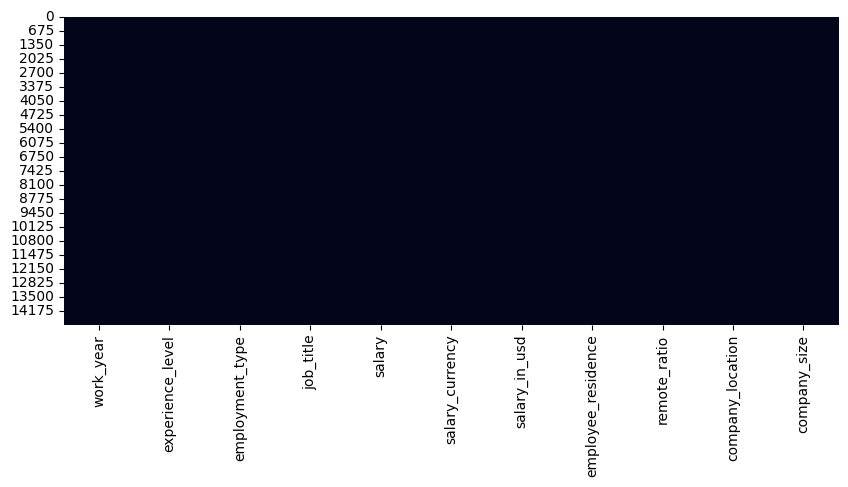

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 4))
sns.heatmap(df.isna(), cbar = False)
plt.show()

In [10]:
df.duplicated().sum()
df[df.duplicated()]

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
72,2024,MI,FT,Machine Learning Scientist,750000,USD,750000,US,0,US,M
84,2024,MI,FT,Research Engineer,720000,USD,720000,US,0,US,M
93,2024,SE,FT,Machine Learning Engineer,550000,USD,550000,US,0,US,M
97,2024,SE,FT,Research Scientist,500000,USD,500000,US,100,US,M
105,2024,MI,FT,Research Engineer,440000,USD,440000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
14787,2022,MI,FT,Data Engineer,24000,USD,24000,US,0,US,M
14792,2024,EN,FT,Data Analyst,23000,GBP,28750,GB,0,GB,M
14793,2024,EN,FT,Data Analyst,23000,GBP,28750,GB,0,GB,M
14794,2024,EN,FT,Data Analyst,23000,GBP,28750,GB,0,GB,M


Số lượng trùng lặp khá nhiều ~1/3 số lượng của data
Vì dataset là do dữ liệu cộng đồng đóng góp nên:
- Nhiều bản ghi được upload nhiều lần
- Cùng 1 job -> nhiều người báo cáo lại giống nhau
- Cùng salary, cùng vị trí, cùng location -> bị lặp
- Một số job full time có salary cố định -> duplicated

-> Số lượng duplicated có thể nhiều là điều bình thường

In [11]:
# outliers

import numpy as np
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['salary_in_usd'] < lower) | (df['salary_in_usd'] > upper)]
len(outliers)



270

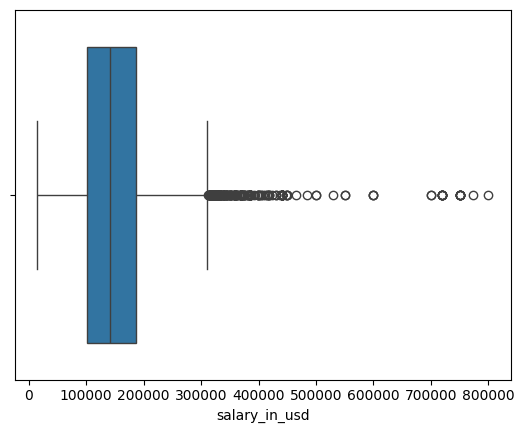

In [12]:
sns.boxplot(data = df, x = 'salary_in_usd')
plt.show()

In [13]:
print(df['experience_level'].value_counts())
print(df['company_size'].value_counts())
print(df['employment_type'].value_counts())

experience_level
SE    9696
MI    3553
EN    1148
EX     441
Name: count, dtype: int64
company_size
M    13674
L      983
S      181
Name: count, dtype: int64
employment_type
FT    14772
PT       27
CT       26
FL       13
Name: count, dtype: int64


In [36]:
# Kiểm tra giá trị hợp lệ theo domain knowledge experience_level (chỉ được: EN, MI, SE, EX)
valid_experience = {'EN', 'MI', 'SE', 'EX'}
invalid_experience = df[~df['experience_level'].isin(valid_experience)]

invalid_experience[['experience_level']].value_counts()


,count
experience_level,


In [38]:
# employment_type (FT, PT, CT, FL)

valid_employment = {'FT', 'PT', 'CT', 'FL'}
df[~df['employment_type'].isin(valid_employment)]['employment_type'].value_counts()


,count
employment_type,


In [39]:
# company_size (S, M, L)

valid_company_size = {'S', 'M', 'L'}
df[~df['company_size'].isin(valid_company_size)]['company_size'].value_counts()


,count
company_size,


In [40]:
# country codes (ISO-2 uppercase)

# employee_residence
df['employee_residence'].str.len().value_counts()

# company_location
df['company_location'].str.len().value_counts()


,count
company_location,
2,14838


In [41]:
# job_title – kiểm tra variation không mong muốn
df['job_title'].value_counts().head(20)



,count
job_title,
Data Engineer,3162
Data Scientist,3015
Data Analyst,2189
Machine Learning Engineer,1542
Research Scientist,475
Analytics Engineer,403
Applied Scientist,383
Data Architect,369
Research Engineer,276


In [42]:
# Kiểm tra năm hợp lệ (2020–2024) (work_year)
df['work_year'].describe()


,work_year
count,14838.000000
mean,2023.138900
std,0.700799
min,2020.000000
25%,2023.000000
50%,2023.000000
75%,2024.000000
max,2024.000000


In [43]:
invalid_years = df[(df['work_year'] < 2020) | (df['work_year'] > 2024)]
len(invalid_years)


0

In [44]:
# salary & salary_in_usd (không được âm / bằng 0)
df[df['salary'] <= 0].shape
df[df['salary_in_usd'] <= 0].shape


(0, 11)

In [45]:
# remote_ratio (chỉ được {0, 50, 100})
df['remote_ratio'].value_counts()


,count
remote_ratio,
0,9853
100,4737
50,248


In [48]:
# Salary out-of-domain (phi thực tế)
# Ví dụ: lương > 1 triệu USD / năm -> đánh dấu là outliers kinh tế

extreme_salary = df[df['salary_in_usd'] > 1000000]
extreme_salary.shape


(0, 11)

# Bước 4: Phân tích đơn biến (Univariate Analysis)

## Biến định lượng (Numerical Variables)

In [49]:
num_cols = ['salary', 'salary_in_usd', 'remote_ratio', 'work_year']


In [50]:
import pandas as pd
from scipy.stats import skew, kurtosis

num_summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Skewness': df[num_cols].apply(lambda x: skew(x.dropna())),
    'Kurtosis': df[num_cols].apply(lambda x: kurtosis(x.dropna()))
})

num_summary


,Mean,Median,Std,Min,Max,Skewness,Kurtosis
salary,165022.718965,142200.0,356235.426522,14000,30400000,50.009186,3693.575689
salary_in_usd,149874.718763,141300.0,69009.181349,15000,800000,1.522631,7.841023
remote_ratio,32.760480,0.0,46.488278,0,100,0.734526,-1.438528
work_year,2023.138900,2023.0,0.700799,2020,2024,-0.807454,1.759323


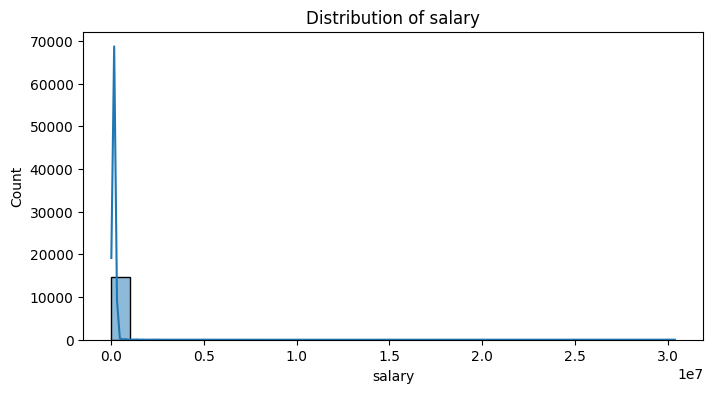

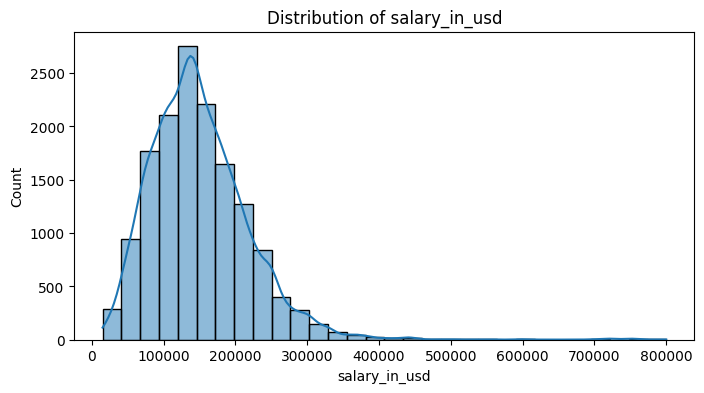

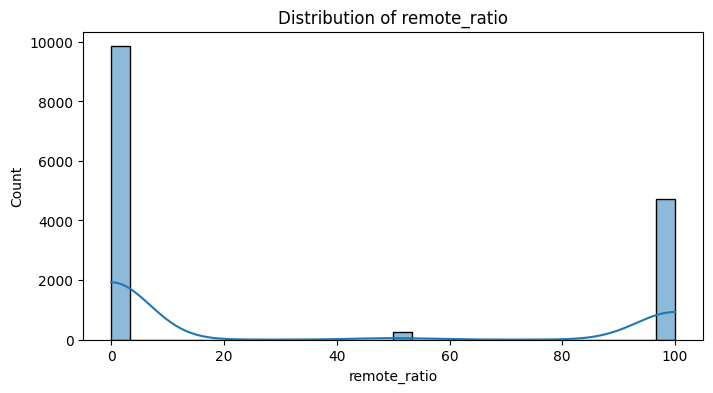

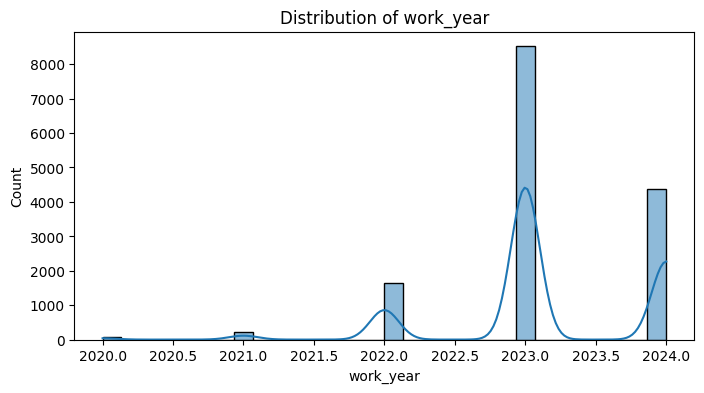

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


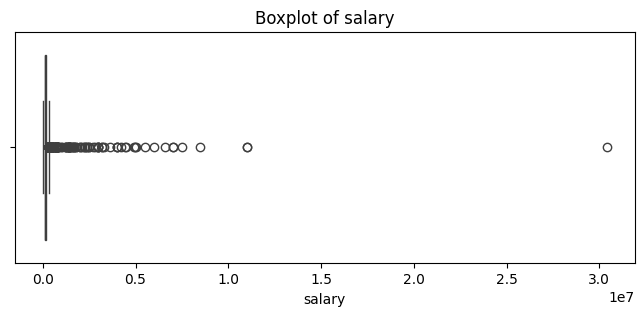

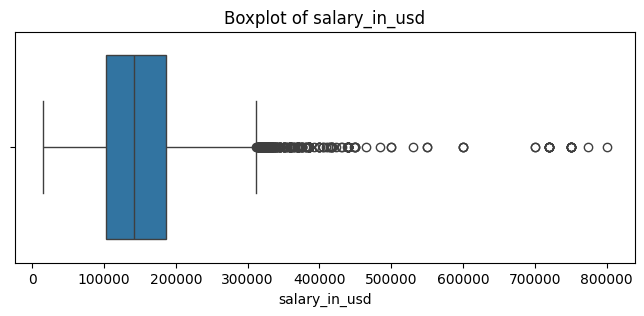

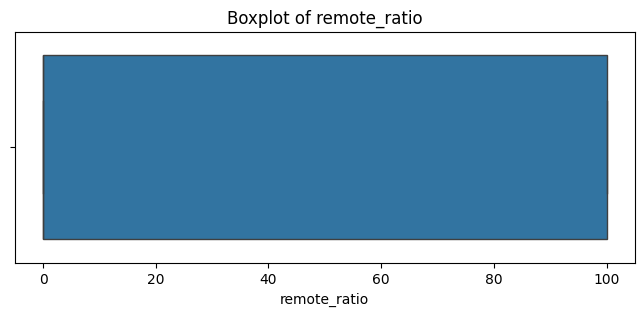

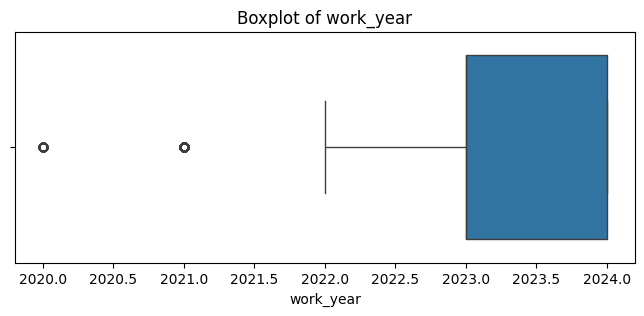

In [52]:
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


## Biến phân loại (Categorical Variables)

In [53]:
cat_cols = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'company_location', 'company_size'
]


In [54]:
cat_summary = {}

for col in cat_cols:
    freq = df[col].value_counts()
    prop = df[col].value_counts(normalize=True)
    mode = df[col].mode()[0]

    cat_summary[col] = pd.DataFrame({
        'Frequency': freq,
        'Proportion': prop
    })

    print(f"\nMode of {col}: {mode}")



Mode of experience_level: SE

Mode of employment_type: FT

Mode of job_title: Data Engineer

Mode of employee_residence: US

Mode of company_location: US

Mode of company_size: M


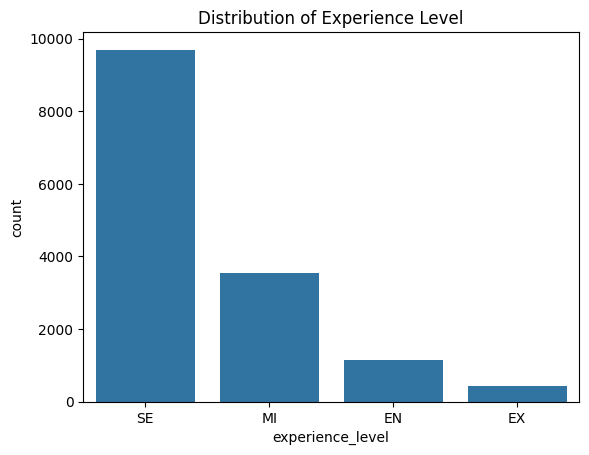

In [55]:
sns.countplot(
    data=df,
    x='experience_level',
    order=df['experience_level'].value_counts().index
)
plt.title('Distribution of Experience Level')
plt.show()


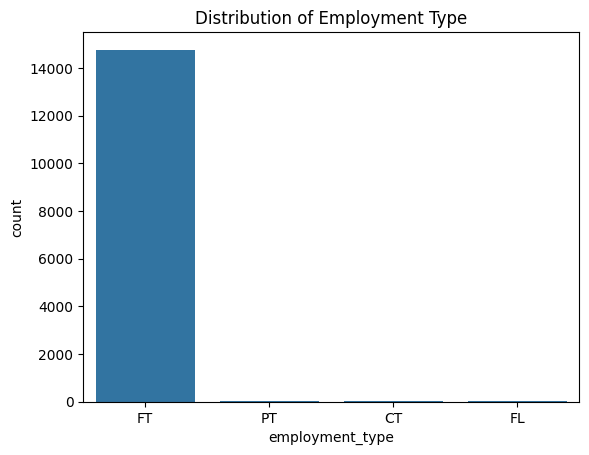

In [56]:
sns.countplot(
    data=df,
    x='employment_type',
    order=df['employment_type'].value_counts().index
)
plt.title('Distribution of Employment Type')
plt.show()


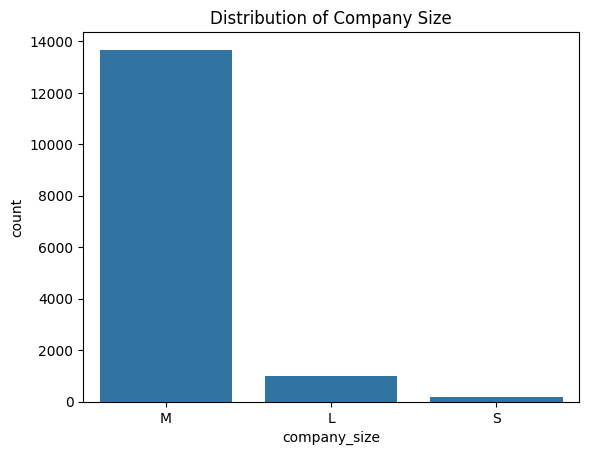

In [57]:
sns.countplot(
    data=df,
    x='company_size',
    order=df['company_size'].value_counts().index
)
plt.title('Distribution of Company Size')
plt.show()


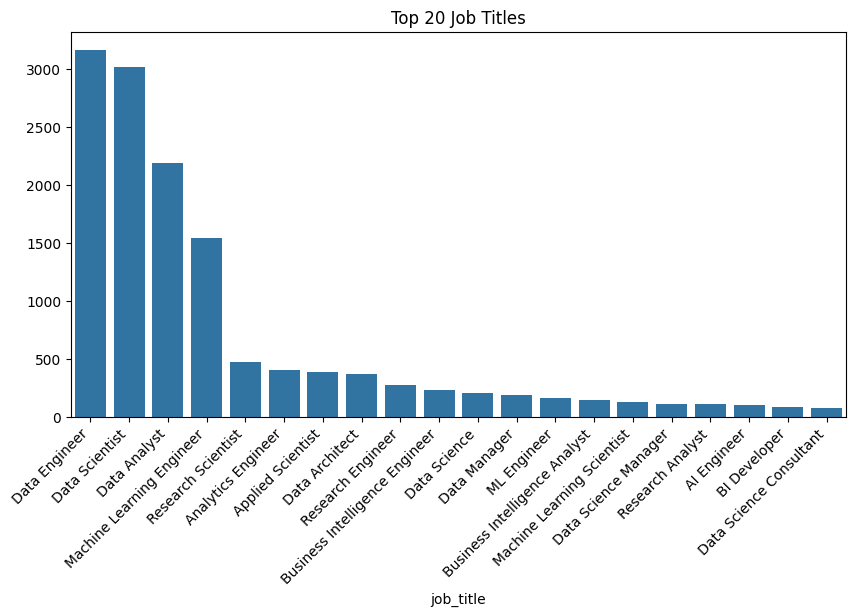

In [60]:
top_n = 20

job_top = df['job_title'].value_counts().head(top_n)

plt.figure(figsize=(10,5))
sns.barplot(x=job_top.index, y=job_top.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Job Titles')
plt.show()


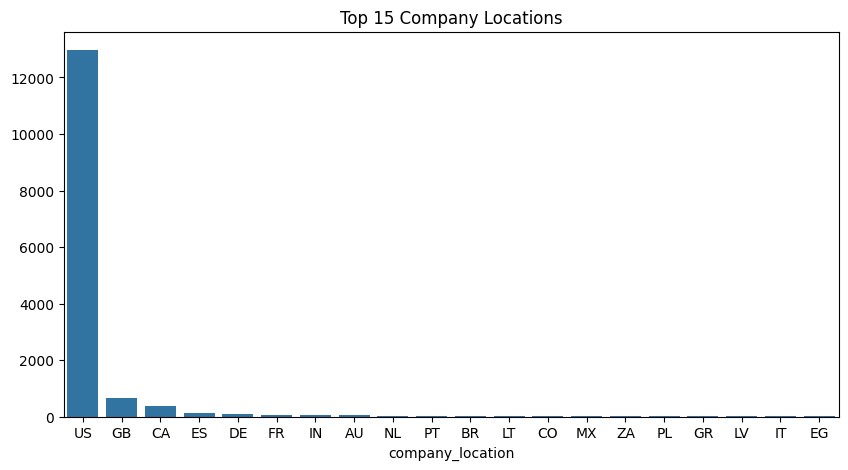

In [61]:
country_top = df['company_location'].value_counts().head(top_n)

plt.figure(figsize=(10,5))
sns.barplot(x=country_top.index, y=country_top.values)
plt.title('Top 15 Company Locations')
plt.show()


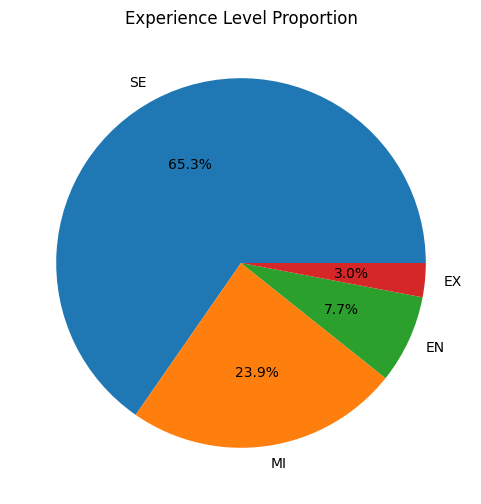

In [62]:
df['experience_level'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title('Experience Level Proportion')
plt.ylabel('')
plt.show()


Nhận xét:
Phân tích đơn biến cho thấy phân phối mức lương (salary_in_usd) có độ lệch phải cao và tồn tại nhiều giá trị ngoại lai, phản ánh sự chênh lệch lớn giữa các vị trí trong ngành khoa học dữ liệu.
Nhóm nhân sự có trình độ Senior (SE) chiếm tỷ trọng lớn nhất, trong khi nhóm Executive (EX) có tỷ lệ thấp nhưng mức lương cao vượt trội.
Phần lớn các vị trí là hợp đồng toàn thời gian (FT) và thuộc các công ty quy mô vừa (M).

# BƯỚC 5 – PHÂN TÍCH ĐA BIẾN (MULTIVARIATE ANALYSIS)

## Biến số vs Biến số (Numerical vs Numerical)

In [63]:
num_cols = ['salary_in_usd', 'remote_ratio', 'work_year']


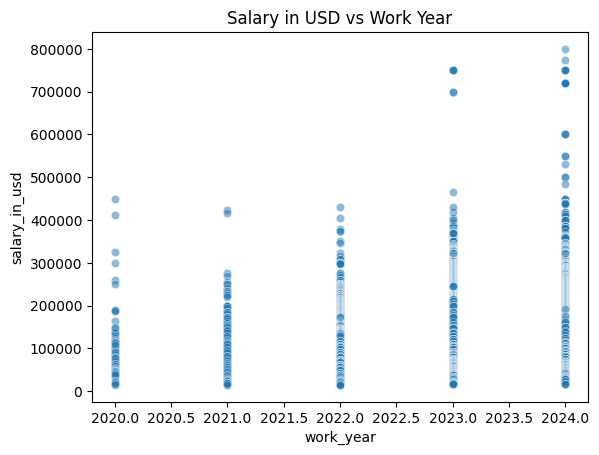

In [66]:
# Scatter plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x='work_year',
    y='salary_in_usd',
    alpha=0.5
)
plt.title('Salary in USD vs Work Year')
plt.show()


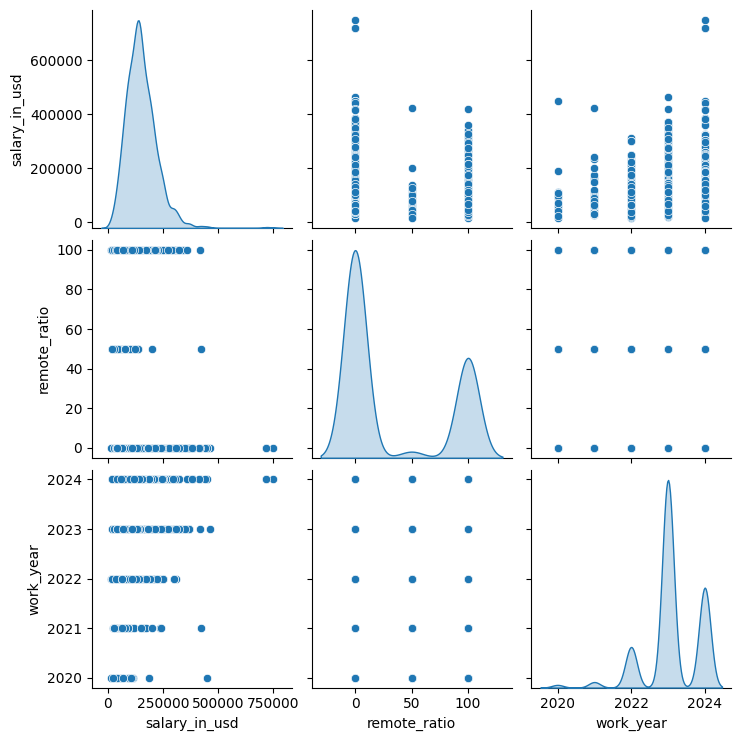

In [67]:
# Pairplot
sns.pairplot(
    df[num_cols].sample(2000, random_state=42),
    diag_kind='kde'
)
plt.show()


In [68]:
# Correlation Matrix (Pearson & Spearman)
corr_pearson = df[num_cols].corr(method='pearson')
corr_spearman = df[num_cols].corr(method='spearman')

corr_pearson, corr_spearman


(               salary_in_usd  remote_ratio  work_year
 salary_in_usd       1.000000     -0.064829   0.090873
 remote_ratio       -0.064829      1.000000  -0.204954
 work_year           0.090873     -0.204954   1.000000,
                salary_in_usd  remote_ratio  work_year
 salary_in_usd       1.000000     -0.057003   0.045904
 remote_ratio       -0.057003      1.000000  -0.198608
 work_year           0.045904     -0.198608   1.000000)

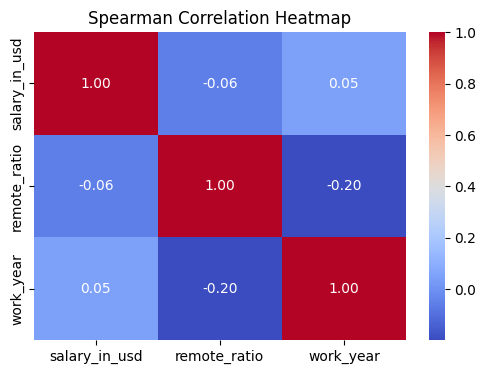

In [69]:
plt.figure(figsize=(6,4))
sns.heatmap(
    corr_spearman,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Spearman Correlation Heatmap')
plt.show()


## Biến số vs Biến phân loại (Numerical vs Categorical)

In [70]:
cat_cols = ['experience_level', 'company_size', 'employment_type']


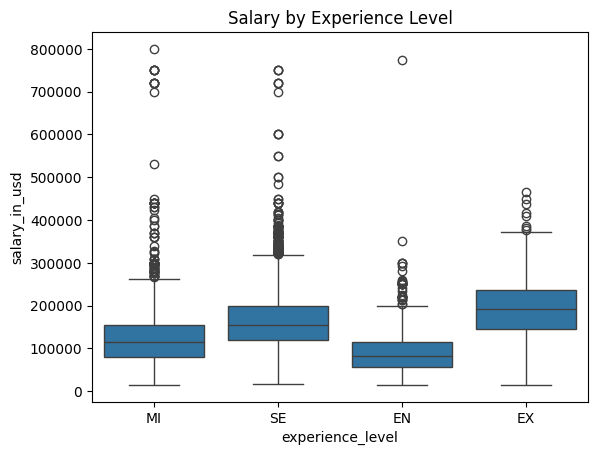

In [71]:
# Salary theo Experience Level
sns.boxplot(
    data=df,
    x='experience_level',
    y='salary_in_usd'
)
plt.title('Salary by Experience Level')
plt.show()


Median lương tăng rõ rệt từ EN → MI → SE → EX

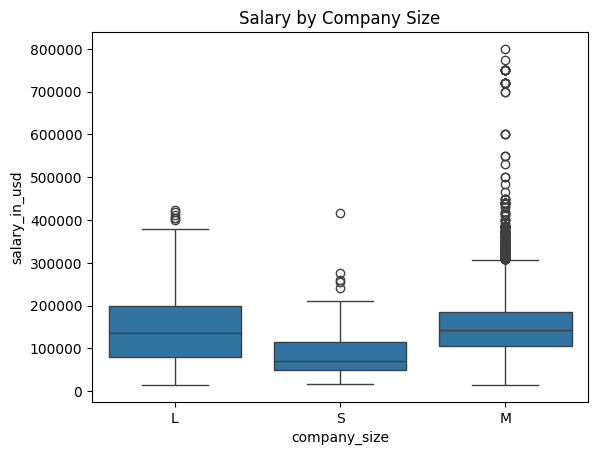

In [72]:
# Salary theo Company Size
sns.boxplot(
    data=df,
    x='company_size',
    y='salary_in_usd'
)
plt.title('Salary by Company Size')
plt.show()


Median lương tăng rõ rệt từ S -> M -> L

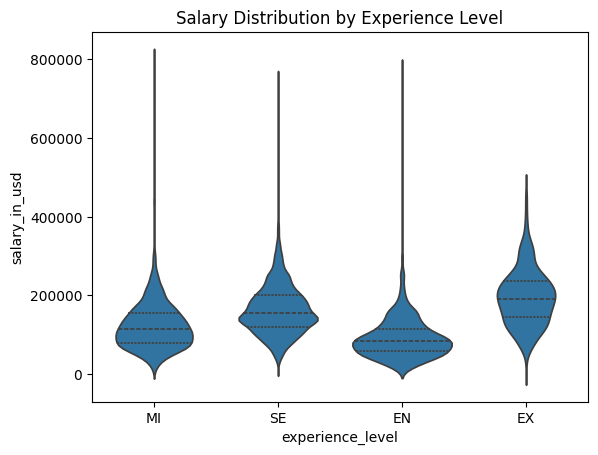

In [73]:
# Violin plot
sns.violinplot(
    data=df,
    x='experience_level',
    y='salary_in_usd',
    inner='quartile'
)
plt.title('Salary Distribution by Experience Level')
plt.show()


## Biến phân loại vs Biến phân loại (Categorical vs Categorical)

In [77]:
# Experience Level × Company Size
ct = pd.crosstab(
    df['experience_level'],
    df['company_size']
)

ct


company_size,L,M,S
experience_level,,,
EN,126,971,51
EX,23,410,8
MI,297,3189,67
SE,537,9104,55


In [78]:
# Cross-tabulation (theo tỷ lệ %)
ct_percent = pd.crosstab(
    df['experience_level'],
    df['company_size'],
    normalize='index'
)

ct_percent


company_size,L,M,S
experience_level,,,
EN,0.109756,0.845819,0.044425
EX,0.052154,0.929705,0.018141
MI,0.083591,0.897551,0.018857
SE,0.055384,0.938944,0.005672


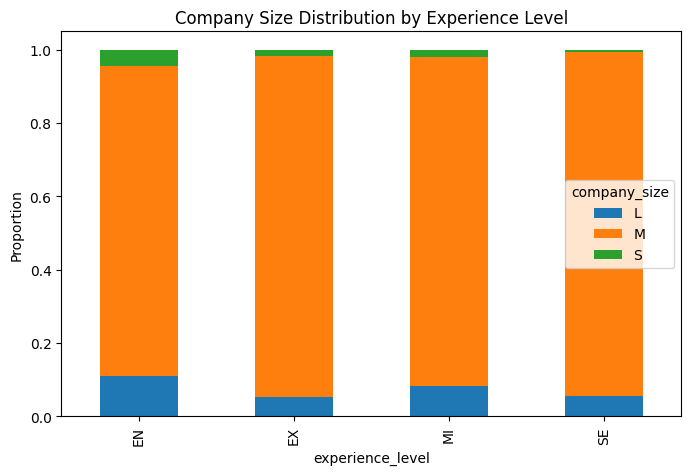

In [79]:
# Stacked Bar Chart
ct_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title('Company Size Distribution by Experience Level')
plt.ylabel('Proportion')
plt.show()


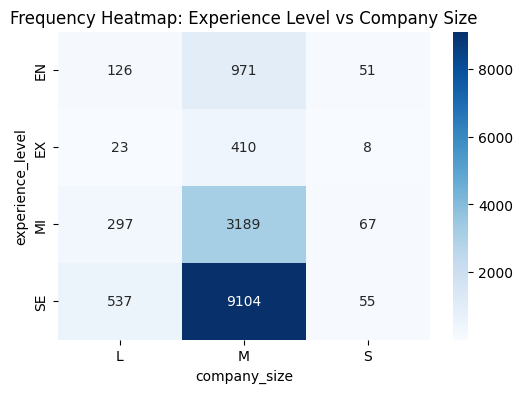

In [80]:
# Heatmap của Frequency Table
plt.figure(figsize=(6,4))
sns.heatmap(
    ct,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Frequency Heatmap: Experience Level vs Company Size')
plt.show()


Kết quả phân tích cho thấy trình độ kinh nghiệm và quy mô công ty có mối quan hệ chặt chẽ.
Các công ty lớn tập trung nhiều nhân sự có kinh nghiệm cao, trong khi các công ty vừa đóng vai trò quan trọng trong việc tiếp nhận và phát triển nhân sự mới.
Điều này gợi ý rằng kinh nghiệm làm việc là yếu tố then chốt ảnh hưởng đến khả năng gia nhập các tổ chức quy mô lớn trong lĩnh vực khoa học dữ liệu.

# Phân tích nâng cao

## Time series: Xu hướng, mùa vụ, ACF/PACF

In [81]:
# Xu hướng lương theo năm (mean/median)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

year_stats = df.groupby('work_year')['salary_in_usd'].agg(['count','mean','median']).reset_index()
year_stats


,work_year,count,mean,median
0,2020,75,102250.866667,79833.0
1,2021,218,99922.073394,83872.0
2,2022,1652,134404.072034,132000.0
3,2023,8519,153732.664632,145000.0
4,2024,4374,151510.094422,140000.0


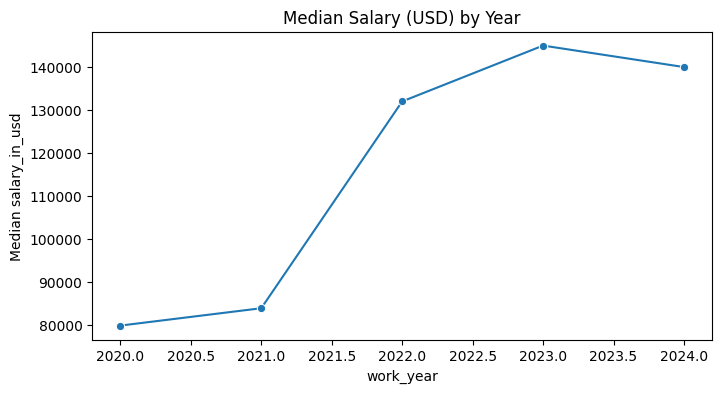

In [82]:
plt.figure(figsize=(8,4))
sns.lineplot(data=year_stats, x='work_year', y='median', marker='o')
plt.title('Median Salary (USD) by Year')
plt.ylabel('Median salary_in_usd')
plt.show()


Bảng thống kê và biểu đồ đường cho thấy xu hướng biến động rõ rệt của mức lương trung vị (median salary_in_usd) theo năm:

Giai đoạn 2020–2021:
Mức lương trung vị tăng nhẹ từ 79,833 USD (2020) lên 83,872 USD (2021). Giai đoạn này chịu ảnh hưởng của đại dịch COVID-19, thị trường lao động công nghệ còn nhiều bất ổn, tốc độ tăng lương tương đối chậm.

Giai đoạn 2021–2022:
Ghi nhận mức tăng mạnh và đột biến, với median salary tăng từ 83,872 USD lên 132,000 USD. Điều này phản ánh sự bùng nổ nhu cầu nhân lực Data Science và AI khi doanh nghiệp đẩy mạnh chuyển đổi số sau đại dịch.

Năm 2023:
Mức lương trung vị tiếp tục tăng và đạt đỉnh ở 145,000 USD, cho thấy thị trường lao động trong lĩnh vực khoa học dữ liệu đạt trạng thái “nóng”, đặc biệt với các vị trí có kinh nghiệm cao.

Năm 2024:
Median salary giảm nhẹ xuống 140,000 USD, dù số lượng quan sát vẫn lớn. Sự sụt giảm này có thể phản ánh xu hướng điều chỉnh thị trường, khi các công ty tối ưu chi phí và tuyển dụng thận trọng hơn.

Về số lượng mẫu (count):
Dữ liệu tập trung chủ yếu ở các năm gần đây (2022–2024), đặc biệt là năm 2023, giúp các kết luận trong giai đoạn này có độ tin cậy cao hơn so với các năm đầu (2020–2021) có ít quan sát.

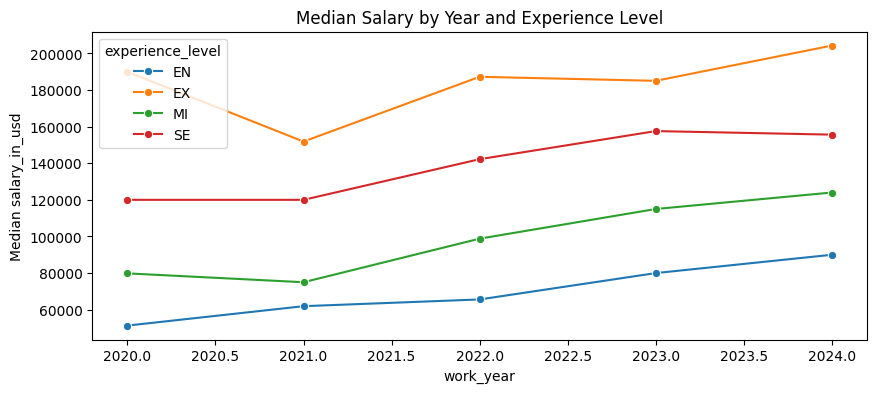

In [83]:
# Xu hướng theo năm + nhóm kinh nghiệm
year_exp = df.groupby(['work_year','experience_level'])['salary_in_usd'].median().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(data=year_exp, x='work_year', y='salary_in_usd', hue='experience_level', marker='o')
plt.title('Median Salary by Year and Experience Level')
plt.ylabel('Median salary_in_usd')
plt.show()


1. Sự phân tầng lương rõ rệt theo trình độ kinh nghiệm

Ở tất cả các năm, mức lương trung vị tuân theo thứ tự ổn định:

Executive (EX) > Senior (SE) > Mid-level (MI) > Entry-level (EN)

Khoảng cách lương giữa các nhóm là rất đáng kể, đặc biệt giữa EX và các nhóm còn lại, phản ánh vai trò chiến lược và mức độ trách nhiệm cao của các vị trí điều hành.

2. Xu hướng tăng lương mạnh giai đoạn 2021–2023

Tất cả các nhóm kinh nghiệm đều ghi nhận mức tăng lương rõ rệt từ năm 2021 sang 2022, phù hợp với giai đoạn bùng nổ nhu cầu nhân lực Data Science và AI hậu COVID-19.

Nhóm Mid-level (MI) và Senior (SE) có tốc độ tăng tương đối ổn định và bền vững, cho thấy nhu cầu cao đối với lực lượng chuyên môn nòng cốt.

3. Nhóm Executive (EX) biến động mạnh nhất

Mức lương trung vị của nhóm EX giảm nhẹ năm 2021, sau đó tăng mạnh và đạt mức cao nhất vào năm 2024 (trên 200,000 USD).

Điều này phản ánh tính nhạy cảm của lương cấp cao với chu kỳ thị trường, cũng như sự khan hiếm của các vị trí lãnh đạo dữ liệu.

4. Nhóm Entry-level (EN) tăng trưởng chậm nhưng ổn định

Lương trung vị của EN tăng đều qua các năm, từ khoảng 50,000 USD (2020) lên gần 90,000 USD (2024).

Tuy nhiên, khoảng cách với các nhóm kinh nghiệm cao không thu hẹp, cho thấy kinh nghiệm vẫn là yếu tố quyết định chính trong tăng trưởng thu nhập.

Kết luận: Kết quả phân tích cho thấy trình độ kinh nghiệm có tác động mạnh và nhất quán đến mức lương trong lĩnh vực khoa học dữ liệu.
Mặc dù mức lương có xu hướng tăng theo thời gian cho tất cả các nhóm, sự chênh lệch giữa các mức kinh nghiệm vẫn được duy trì, đặc biệt là đối với các vị trí Senior và Executive.
Điều này gợi ý rằng đầu tư vào tích lũy kinh nghiệm chuyên môn và kỹ năng lãnh đạo là yếu tố then chốt cho quyết định nghề nghiệp dài hạn trong lĩnh vực này.

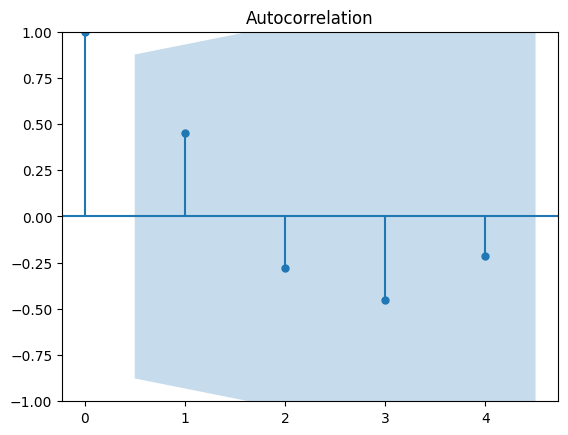

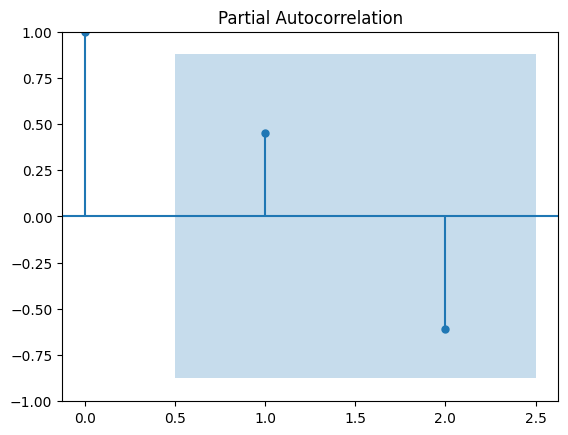

In [85]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ts = year_stats.set_index('work_year')['median']

plot_acf(ts, lags=4)
plt.show()

plot_pacf(ts, lags=2, method='ywm')
plt.show()


## Text data: Word cloud, length distribution, sentiment

In [86]:
# Phân phối độ dài job_title (length distribution)
df['job_title_len'] = df['job_title'].astype(str).str.len()

df['job_title_len'].describe()


,job_title_len
count,14838.000000
mean,16.128117
std,5.241434
min,9.000000
25%,13.000000
50%,14.000000
75%,18.000000
max,40.000000


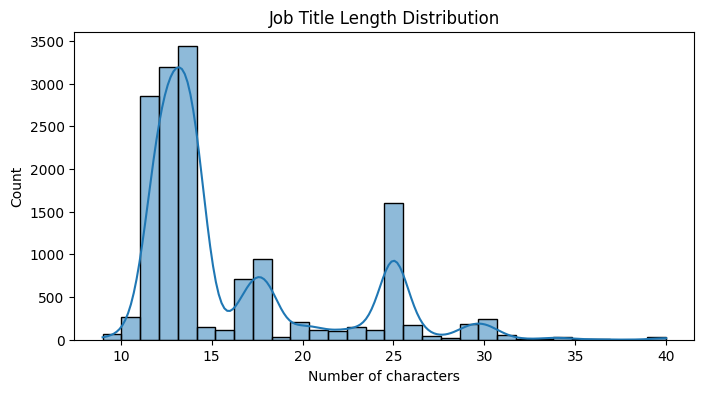

In [87]:
plt.figure(figsize=(8,4))
sns.histplot(df['job_title_len'], kde=True, bins=30)
plt.title('Job Title Length Distribution')
plt.xlabel('Number of characters')
plt.show()


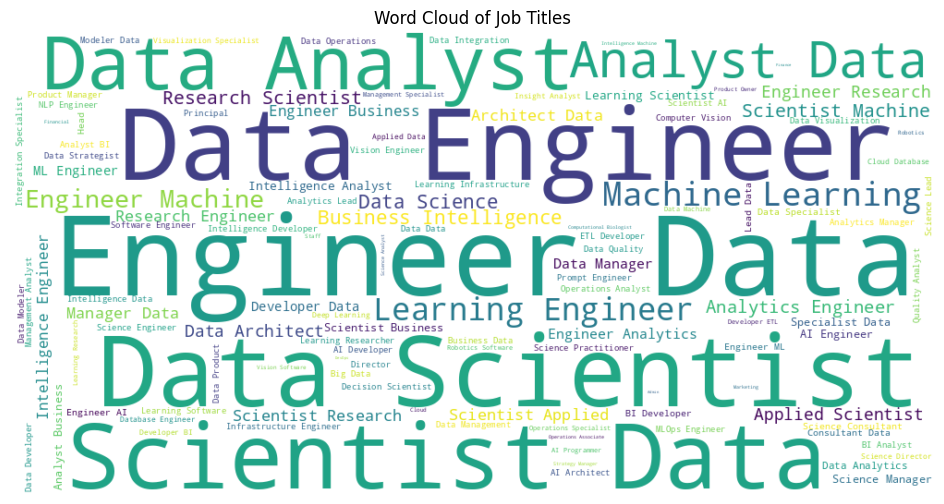

In [88]:
# Word cloud cho job_title
from wordcloud import WordCloud

text = " ".join(df['job_title'].astype(str).tolist())

wc = WordCloud(width=1000, height=500, background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Job Titles')
plt.show()


Phân tích độ dài chuỗi của biến job_title cho thấy một số đặc điểm đáng chú ý:

Độ dài trung bình của job title là 16.13 ký tự, với median = 14, cho thấy phần lớn các chức danh có độ dài tương đối ngắn và súc tích.

Phân phối tập trung chủ yếu trong khoảng 13–18 ký tự (từ Q1 đến Q3), phản ánh việc ngành khoa học dữ liệu sử dụng các tên gọi chức danh mang tính tiêu chuẩn như Data Scientist, Data Engineer, ML Engineer.

Giá trị min = 9 và max = 40 cho thấy tồn tại một số chức danh rất ngắn (ví dụ AI Lead) và một số chức danh dài, thường là các vai trò cấp cao hoặc chuyên biệt (ví dụ Lead Machine Learning Engineer).

Biểu đồ histogram kết hợp KDE cho thấy phân phối không đối xứng và có xu hướng đa đỉnh (multimodal), phản ánh sự tồn tại của nhiều nhóm job title khác nhau (nhóm kỹ thuật ngắn gọn, nhóm quản lý/chuyên sâu dài hơn).

Đuôi phải dài cho thấy một số ít job title có độ dài lớn, tuy nhiên đây không phải dữ liệu lỗi mà phản ánh đúng sự đa dạng trong cách đặt tên vị trí công việc.

In [89]:
# Sentiment
from textblob import TextBlob

df['job_title_sentiment'] = df['job_title'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

df['job_title_sentiment'].describe()


,job_title_sentiment
count,14838.000000
mean,0.000067
std,0.004787
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.400000


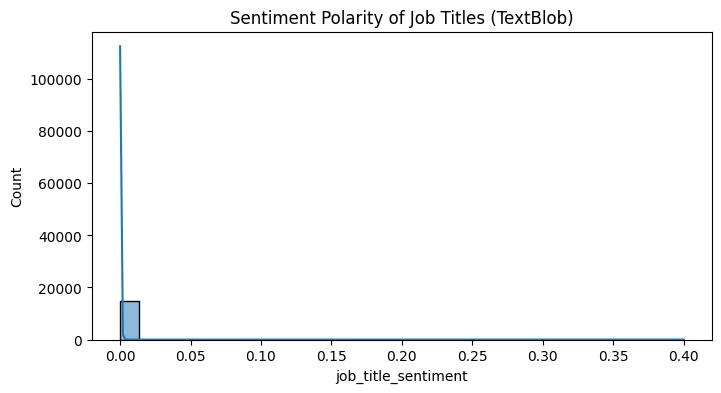

In [90]:
plt.figure(figsize=(8,4))
sns.histplot(df['job_title_sentiment'], kde=True, bins=30)
plt.title('Sentiment Polarity of Job Titles (TextBlob)')
plt.show()


# Bước 7: Tổng hợp và báo cáo
• Ghi chú tất cả phát hiện quan trọng, quyết định xử lý.

7.1. Tóm tắt các phát hiện quan trọng (Key Findings)
- (1) Chất lượng dữ liệu

Dataset gồm 14,838 bản ghi và 11 biến, không có giá trị thiếu (missing values).

Tồn tại số lượng lớn bản ghi trùng lặp hoàn toàn (~1/3 dữ liệu).
Đây là hiện tượng bình thường do dữ liệu được thu thập từ cộng đồng, nhiều người báo cáo cùng một vị trí công việc với thông tin giống nhau.

Các biến phân loại (experience_level, employment_type, company_size, mã quốc gia) nhất quán và hợp lệ theo domain knowledge.

Không phát hiện giá trị thời gian không hợp lệ (work_year chỉ trong khoảng 2020–2024).

Không có mức lương âm hoặc bằng 0; các giá trị lương rất cao được xem là outliers hợp lệ về mặt kinh tế, phản ánh các vị trí cấp cao.

- (2) Phân phối mức lương

Biến salary (theo tiền tệ gốc) có phân phối lệch phải cực mạnh, không phù hợp để so sánh trực tiếp.

Biến salary_in_usd có độ lệch phải vừa phải, tồn tại outliers nhưng phản ánh đúng thực tế thị trường lao động.

Median salary_in_usd được chọn làm thước đo trung tâm chính, vì ổn định hơn mean trong bối cảnh phân phối lệch.

- (3) Phân tích đơn biến

Nhóm Senior (SE) chiếm tỷ trọng lớn nhất trong dataset; Executive (EX) có số lượng ít nhưng mức lương cao vượt trội.

Phần lớn các vị trí là full-time (FT) và tập trung ở công ty quy mô vừa (M).

Job title có độ dài trung bình khoảng 16 ký tự, phân phối đa đỉnh, phản ánh sự đa dạng vai trò trong ngành.

- (4) Phân tích đa biến

Trình độ kinh nghiệm có tác động mạnh và nhất quán đến mức lương:

EX > SE > MI > EN (ở mọi năm).

Quy mô công ty ảnh hưởng rõ rệt đến lương, với median salary tăng từ S → M → L.

-- Phân tích bảng chéo cho thấy:

Nhân sự Senior và Executive tập trung chủ yếu ở công ty quy mô lớn.

Công ty vừa đóng vai trò quan trọng trong việc tiếp nhận Entry và Mid-level.

- (5) Phân tích nâng cao – xu hướng theo thời gian

Mức lương trung vị tăng nhẹ giai đoạn 2020–2021, tăng mạnh 2021–2023, đạt đỉnh năm 2023, và giảm nhẹ năm 2024.

-- Xu hướng này phản ánh:

Giai đoạn hậu COVID: bùng nổ nhu cầu nhân lực Data Science & AI.

Năm 2024: điều chỉnh thị trường, tuyển dụng thận trọng hơn.

Tất cả các nhóm kinh nghiệm đều tăng lương theo thời gian, nhưng khoảng cách giữa các nhóm không thu hẹp.

7.2. Quyết định xử lý dữ liệu (Data Handling Decisions)

Giữ lại biến salary_in_usd làm biến mục tiêu chính, loại bỏ salary khỏi các phân tích so sánh.

Không loại bỏ outliers lương, vì chúng mang ý nghĩa kinh tế (vai trò cấp cao, thị trường Mỹ).

Duplicate records không bị loại bỏ ở bước EDA, nhưng cần lưu ý khi sử dụng dữ liệu cho mô hình dự đoán sau này (có thể cần deduplicate).

Các biến phân loại không cần chuẩn hoá thêm, vì đã nhất quán và hợp lệ.

remote_ratio được xem như biến bán phân loại (ordinal) thay vì biến liên tục.

7.3. Trả lời câu hỏi nghiên cứu

Trình độ kinh nghiệm và quy mô công ty có tác động đáng kể đến mức lương trong lĩnh vực khoa học dữ liệu.

Kinh nghiệm là yếu tố quan trọng nhất quyết định thu nhập.

Công ty quy mô lớn thường trả lương cao hơn và thu hút nhân sự có kinh nghiệm cao.

Đối với sinh viên và người mới vào ngành, công ty quy mô vừa là điểm khởi đầu phổ biến, trong khi công ty lớn phù hợp cho giai đoạn phát triển nghề nghiệp sau này.

7.4. Hạn chế & Hướng phát triển tiếp theo

Dataset mang tính tự báo cáo (self-reported) → có thể tồn tại bias.

Dữ liệu chỉ có mức năm, không đủ chi tiết để phân tích mùa vụ thực sự.

Trong tương lai có thể:

Chuẩn hoá job title (NLP clustering).

Thực hiện kiểm định thống kê (ANOVA, Kruskal-Wallis).

Xây dựng mô hình dự đoán mức lương.